# Wireless Autoencoder: Learning QAM Constellations
This notebook explores higher-order modulation ($M=64$) and replaces the strict L2 peak-power constraint with an **average power constraint**. By allowing symbols to have different amplitudes, the autoencoder can learn grid-like structures similar to Quadrature Amplitude Modulation (QAM).

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define the Communication Autoencoder with Average Power Constraint
class WirelessAutoencoderQAM(nn.Module):
    def __init__(self, M, n_channel_dims):
        super(WirelessAutoencoderQAM, self).__init__()
        self.M = M
        self.n_dims = n_channel_dims
        
        # Transmitter (Encoder)
        # For M=64, we might need a slightly larger hidden layer
        self.encoder = nn.Sequential(
            nn.Linear(self.M, self.M * 2),
            nn.ReLU(),
            nn.Linear(self.M * 2, self.n_dims) 
        )
        
        # Receiver (Decoder)
        self.decoder = nn.Sequential(
            nn.Linear(self.n_dims, self.M * 2),
            nn.ReLU(),
            nn.Linear(self.M * 2, self.M)
        )
        
    def forward(self, x, noise_variance):
        # 1. Encode message to channel symbols
        s = self.encoder(x)
        
        # 2. Normalization layer (Average Power Constraint)
        # Instead of normalizing each symbol individually to a circle, we normalize the entire batch
        # so that the average energy per dimension is 1 (total average energy = n_dims).
        avg_power = torch.mean(s**2)
        s_norm = s / torch.sqrt(avg_power + 1e-8)
        
        # 3. Channel Layer: Additive White Gaussian Noise (AWGN)
        noise = torch.randn_like(s_norm) * np.sqrt(noise_variance)
        r = s_norm + noise
        
        # 4. Decode received symbols back to message probabilities
        y = self.decoder(r)
        return y, s_norm


In [2]:
# System Parameters
M = 64       # 64 possible messages (6 bits per symbol)
n_dims = 2   # 2 channel dimensions (I and Q)
NUM_SAMPLES = 100000
BATCH_SIZE = 1024
EPOCHS = 100 # QAM takes longer to converge

random_labels = torch.randint(0, M, (NUM_SAMPLES,))
data_onehot = torch.nn.functional.one_hot(random_labels, num_classes=M).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = WirelessAutoencoderQAM(M, n_dims).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

training_noise_var = 0.01 # Lower noise variance to help M=64 converge initially

print("Starting Training...")
model.train()
for epoch in range(EPOCHS):
    permutation = torch.randperm(data_onehot.size(0))
    epoch_loss = 0
    
    for i in range(0, data_onehot.size(0), BATCH_SIZE):
        indices = permutation[i:i+BATCH_SIZE]
        batch_x = data_onehot[indices].to(device)
        batch_y_labels = random_labels[indices].to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(batch_x, training_noise_var)
        loss = criterion(outputs, batch_y_labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/(NUM_SAMPLES/BATCH_SIZE):.4f}")
print("Training Complete!")


Starting Training...
Epoch [10/100], Loss: 0.1616
Epoch [20/100], Loss: 0.1415
Epoch [30/100], Loss: 0.1333
Epoch [40/100], Loss: 0.1297
Epoch [50/100], Loss: 0.1269
Epoch [60/100], Loss: 0.1263
Epoch [70/100], Loss: 0.1251
Epoch [80/100], Loss: 0.1241
Epoch [90/100], Loss: 0.1242
Epoch [100/100], Loss: 0.1253
Training Complete!


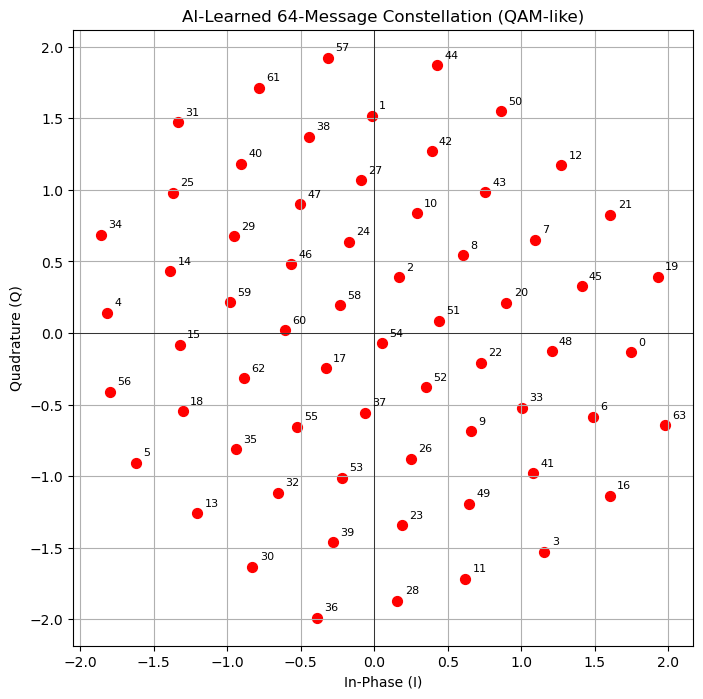

In [3]:
model.eval()
with torch.no_grad():
    # Pass all 64 unique possible messages to see the constellation geometry
    test_identity = torch.eye(M).to(device)
    _, transmitted_symbols = model(test_identity, noise_variance=0)
    transmitted_symbols = transmitted_symbols.cpu().numpy()

plt.figure(figsize=(8, 8))
plt.scatter(transmitted_symbols[:, 0], transmitted_symbols[:, 1], color='red', marker='o', s=50)
for i in range(M):
    plt.annotate(f"{i}", (transmitted_symbols[i, 0]+0.05, transmitted_symbols[i, 1]+0.05), fontsize=8)
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("AI-Learned 64-Message Constellation (QAM-like)")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.show()


Evaluating BLER performance...
Eb/N0 (dB):  0 | BLER: 0.75026
Eb/N0 (dB):  1 | BLER: 0.70960
Eb/N0 (dB):  2 | BLER: 0.66506
Eb/N0 (dB):  3 | BLER: 0.60748
Eb/N0 (dB):  4 | BLER: 0.54430
Eb/N0 (dB):  5 | BLER: 0.47378
Eb/N0 (dB):  6 | BLER: 0.40312
Eb/N0 (dB):  7 | BLER: 0.32702
Eb/N0 (dB):  8 | BLER: 0.25672
Eb/N0 (dB):  9 | BLER: 0.18896
Eb/N0 (dB): 10 | BLER: 0.13050
Eb/N0 (dB): 11 | BLER: 0.08200
Eb/N0 (dB): 12 | BLER: 0.04756
Eb/N0 (dB): 13 | BLER: 0.02404
Eb/N0 (dB): 14 | BLER: 0.01106
Eb/N0 (dB): 15 | BLER: 0.00398
Eb/N0 (dB): 16 | BLER: 0.00092
Eb/N0 (dB): 17 | BLER: 0.00044
Eb/N0 (dB): 18 | BLER: 0.00004
Eb/N0 (dB): 19 | BLER: 0.00000


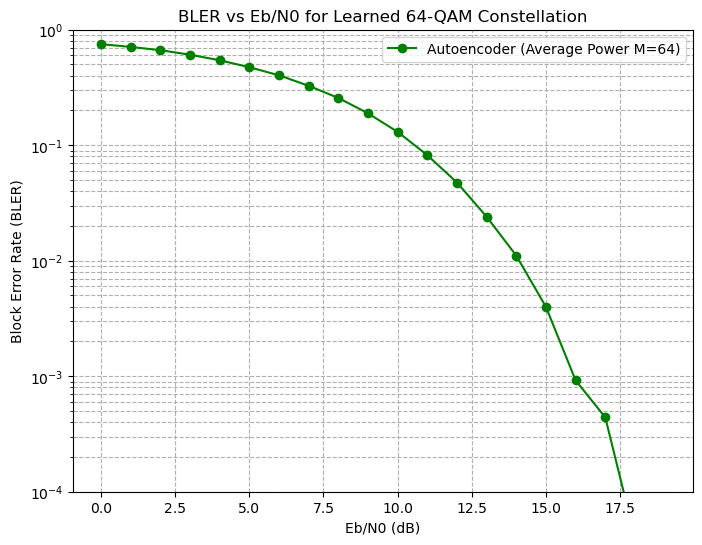

In [4]:
# Evaluate BLER vs Eb/N0
EbN0_dB_range = list(range(0, 20))
bler_qam = []

k = np.log2(M)
R = k / n_dims

TEST_SAMPLES = 50000
test_labels = torch.randint(0, M, (TEST_SAMPLES,))
test_data_onehot = torch.nn.functional.one_hot(test_labels, num_classes=M).float().to(device)
test_labels = test_labels.to(device)

print("Evaluating BLER performance...")
model.eval()
with torch.no_grad():
    for EbN0_dB in EbN0_dB_range:
        EbN0_linear = 10**(EbN0_dB / 10.0)
        noise_var = 1.0 / (2 * R * EbN0_linear)
        
        # The model's batch normalizer uses the average power of the current batch.
        # For testing, our batch is completely random and large, so the average power
        # accurately reflects the constellation's average power.
        outputs, _ = model(test_data_onehot, noise_var)
        predictions = torch.argmax(outputs, dim=1)
        errors = (predictions != test_labels).sum().item()
        bler = errors / TEST_SAMPLES
        bler_qam.append(bler)
        print(f"Eb/N0 (dB): {EbN0_dB:2d} | BLER: {bler:.5f}")

plt.figure(figsize=(8, 6))
plt.semilogy(EbN0_dB_range, bler_qam, 'go-', label='Autoencoder (Average Power M=64)')
plt.grid(True, which="both", ls="--")
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Block Error Rate (BLER)')
plt.title('BLER vs Eb/N0 for Learned 64-QAM Constellation')
plt.legend()
plt.ylim(1e-4, 1)
plt.show()
